In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Set the random seed for reproducibility
np.random.seed(42)

In [3]:
# Create sample dataset with outliers
df = pd.DataFrame({
    'height': np.concatenate([
        np.random.normal(175, 7, 95),  # Normal heights in cm
        np.array([150, 155, 200, 205, 210])  # Outliers
    ]),
    'weight': np.concatenate([
        np.random.normal(70, 10, 95),  # Normal weights in kg
        np.array([40, 45, 120, 125, 130])  # Outliers
    ]),
    'salary': np.concatenate([
        np.random.lognormal(10.5, 0.4, 95),  # Normal salaries
        np.array([500000, 520000, 550000, 600000, 1000000])  # Outliers
    ])
})

In [4]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,178.476999,55.364851,30375.572226
1,174.032150,72.961203,51152.135370
2,179.533820,72.610553,39562.520524
3,185.661209,70.051135,22064.041668
4,173.360926,67.654129,38920.343822


In [5]:
# Quick data summary
df.describe()


,height,weight,salary
count,100.000000,100.000000,100.000000
mean,174.802581,71.397280,70575.816571
std,8.824677,13.932214,138019.017873
min,150.000000,40.000000,9931.760814
25%,170.712081,61.943395,27742.715939
50%,174.111306,70.841072,38441.915870
75%,178.918874,76.333889,51091.331090
max,210.000000,130.000000,1000000.000000


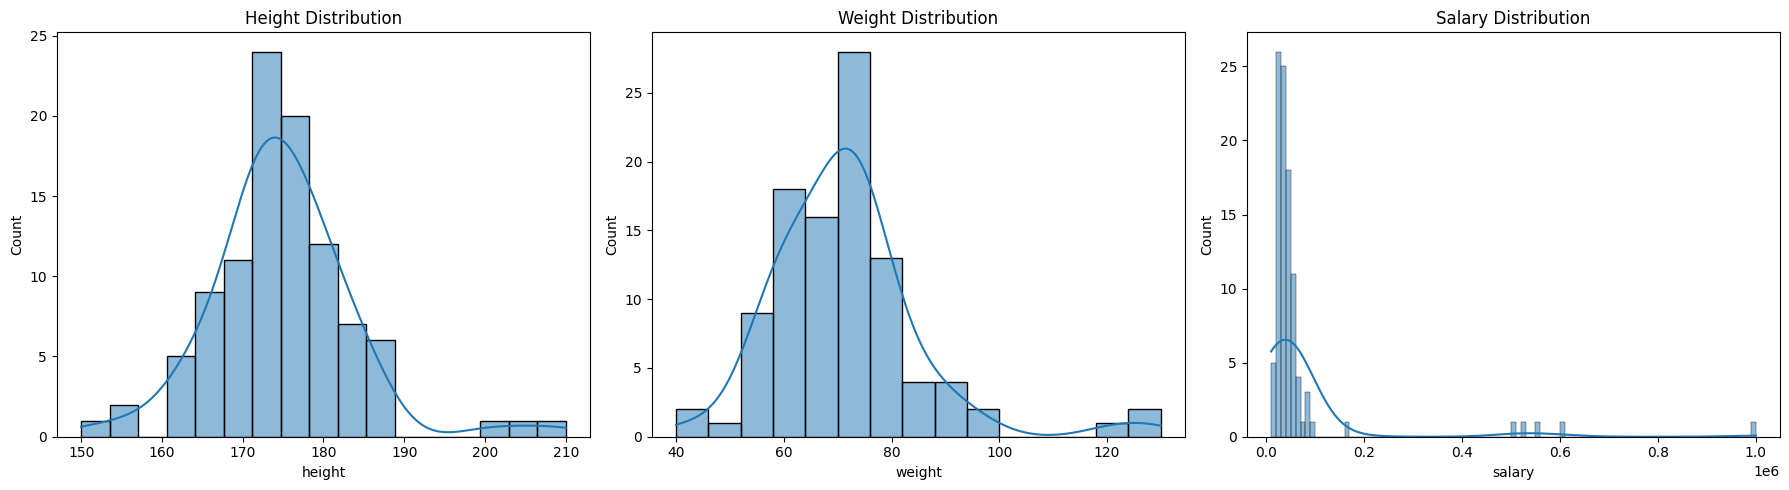

In [6]:
# Visualize distributions to identify potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['height'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')

plt.tight_layout()
plt.show()

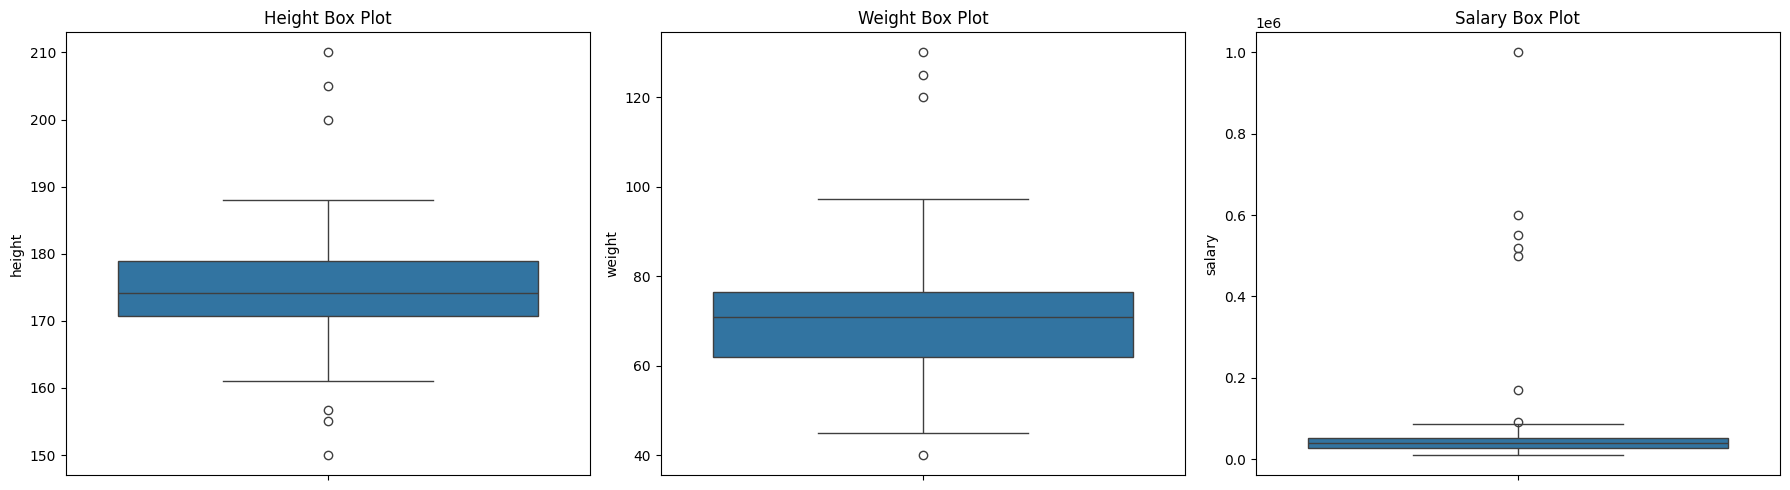

In [7]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

plt.tight_layout()
plt.show()

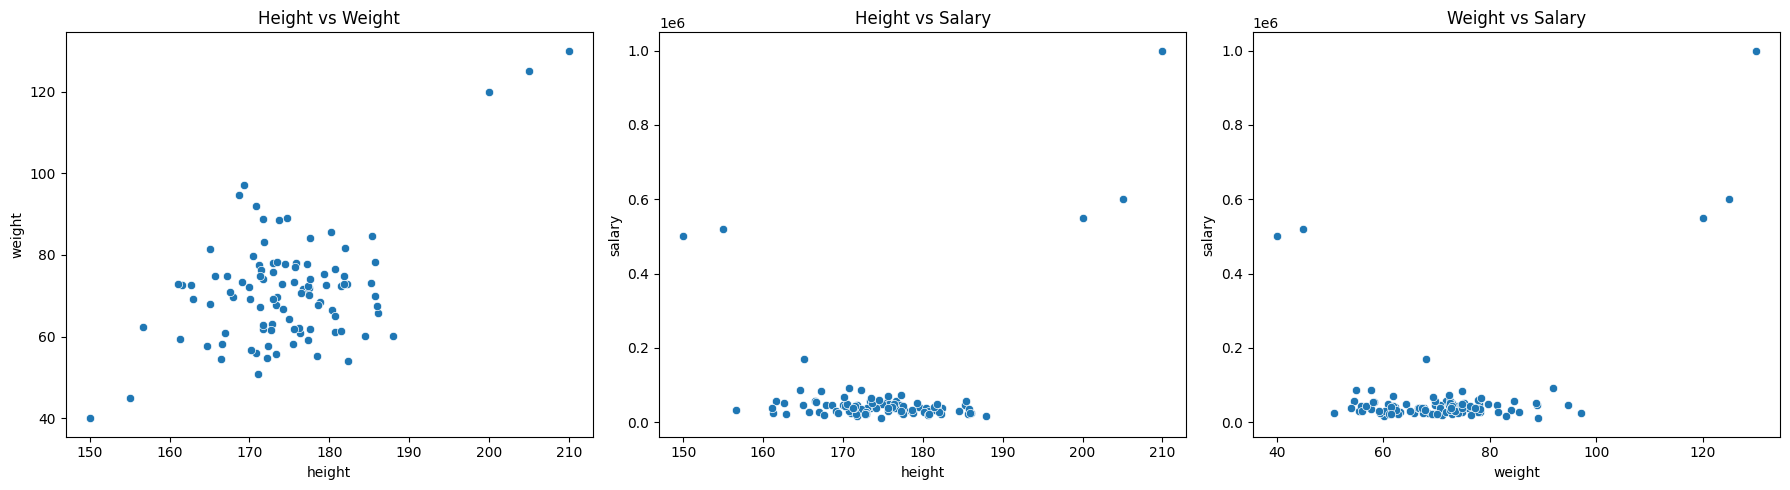

In [8]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [9]:
# Define function for Z-score outlier detection
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]


In [10]:
# Apply Z-score outlier detection
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score): {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score): {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score): {len(salary_outliers_z)} found at indices {salary_outliers_z}")


Height outliers (Z-score): 2 found at indices [98 99]
Weight outliers (Z-score): 3 found at indices [97 98 99]
Salary outliers (Z-score): 5 found at indices [95 96 97 98 99]


In [11]:
# Define function for IQR outlier detection
def detect_outliers_iqr(data, factor=1.5):
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]


In [12]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR): {len(height_outliers_iqr)} found at indices {height_outliers_iqr}")
print(f"Weight outliers (IQR): {len(weight_outliers_iqr)} found at indices {weight_outliers_iqr}")
print(f"Salary outliers (IQR): {len(salary_outliers_iqr)} found at indices {salary_outliers_iqr}")


Height outliers (IQR): 6 found at indices [74 95 96 97 98 99]
Weight outliers (IQR): 4 found at indices [95 97 98 99]
Salary outliers (IQR): 7 found at indices [19 30 95 96 97 98 99]


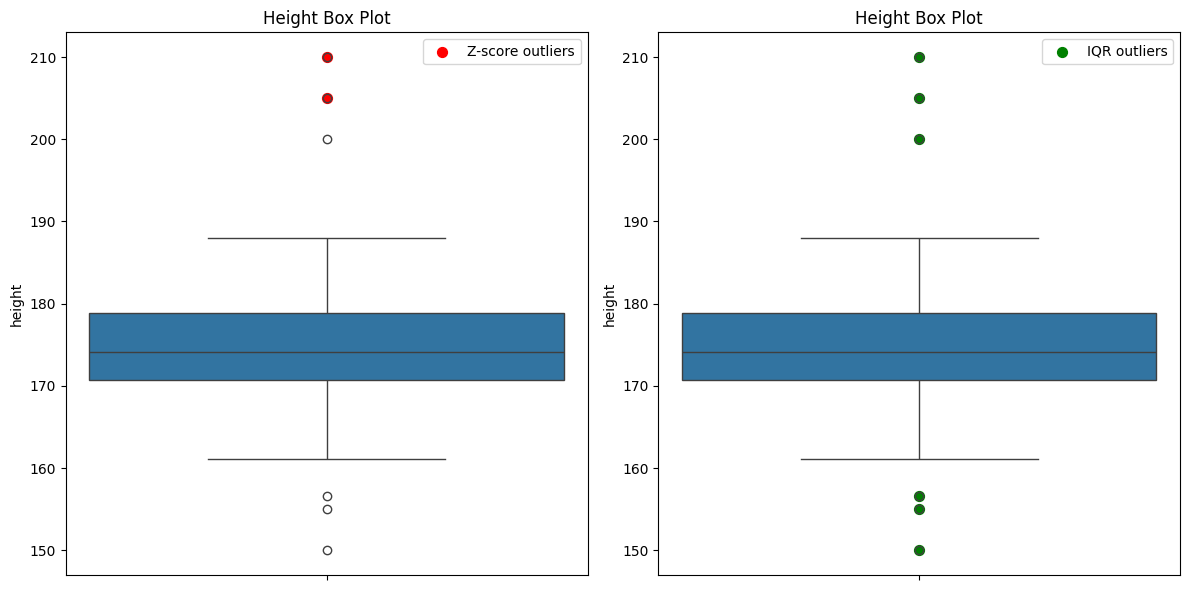

In [13]:
# Visualize the detected outliers for height using box plot with highlighted outliers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z],
            color='red', s=50, label='Z-score outliers')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_iqr), df['height'].iloc[height_outliers_iqr],
            color='green', s=50, label='IQR outliers')
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
# Examining the impact of outliers on statistical measures
print("With outliers:")
print(f"Height mean: {df['height'].mean():.2f}, std: {df['height'].std():.2f}")
print(f"Weight mean: {df['weight'].mean():.2f}, std: {df['weight'].std():.2f}")
print(f"Salary mean: {df['salary'].mean():.2f}, std: {df['salary'].std():.2f}")


With outliers:
Height mean: 174.80, std: 8.82
Weight mean: 71.40, std: 13.93
Salary mean: 70575.82, std: 138019.02


In [15]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")



Without outliers:
Height mean: 174.65, std: 6.18
Weight mean: 70.19, std: 9.50
Salary mean: 39059.91, std: 15713.95


In [16]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)
def winsorize(data, limits=(0.05, 0.05)):
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])


In [17]:
# 3. Log transformation (especially useful for skewed data like salary)
df_log = df.copy()
df_log['salary'] = np.log(df['salary'])


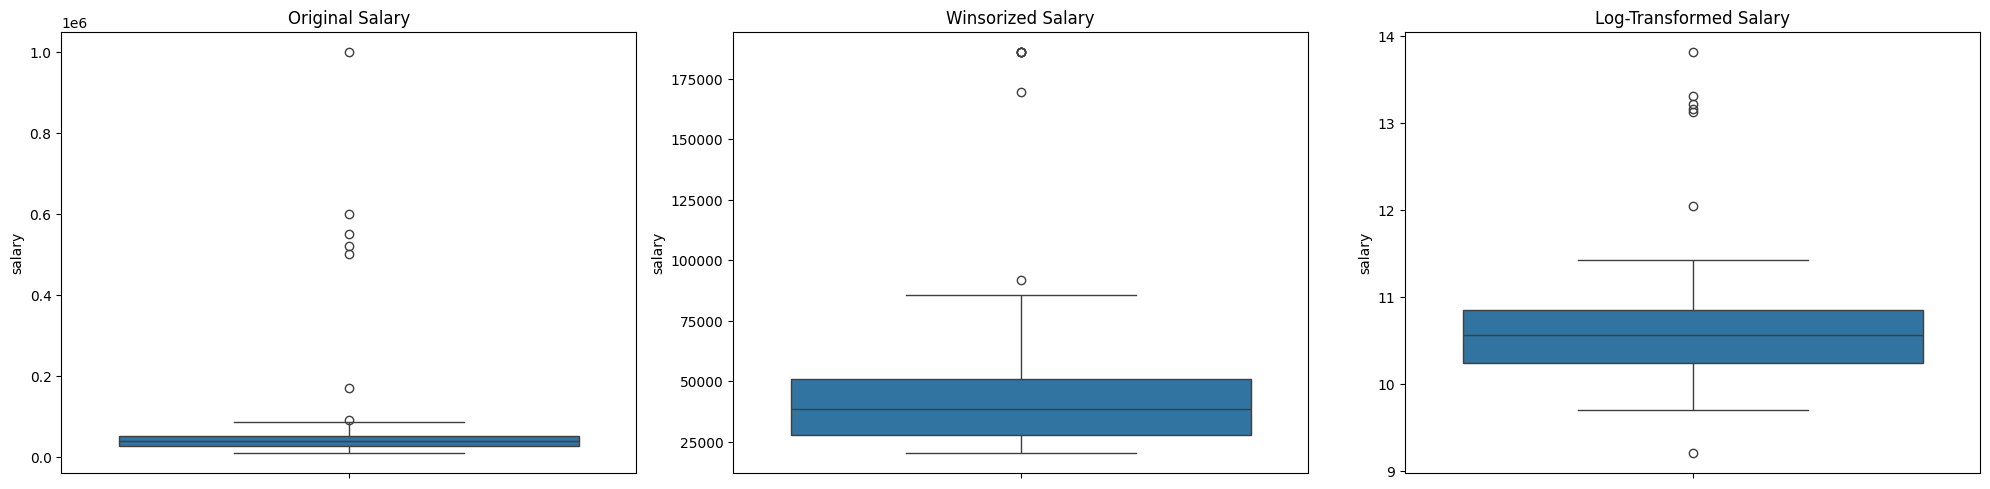

In [18]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [19]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()


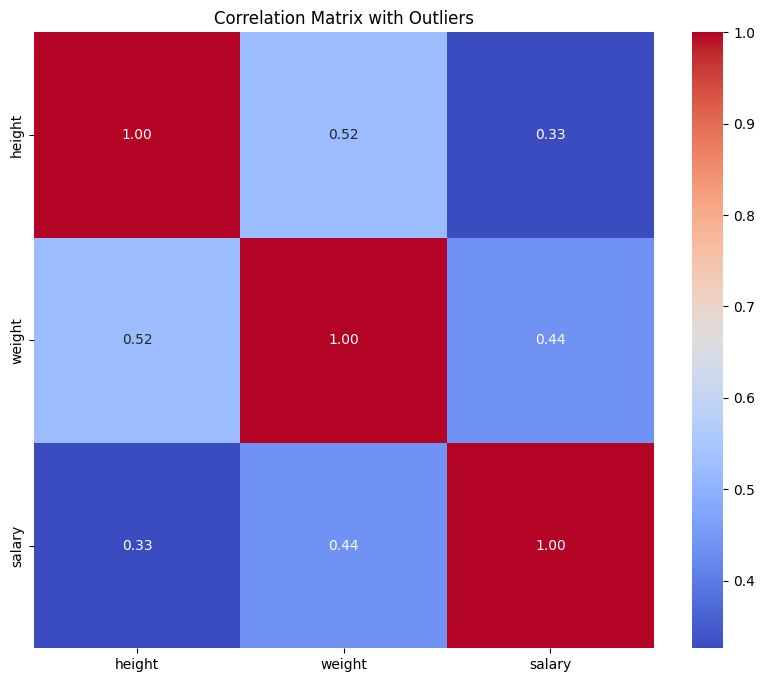

In [20]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()


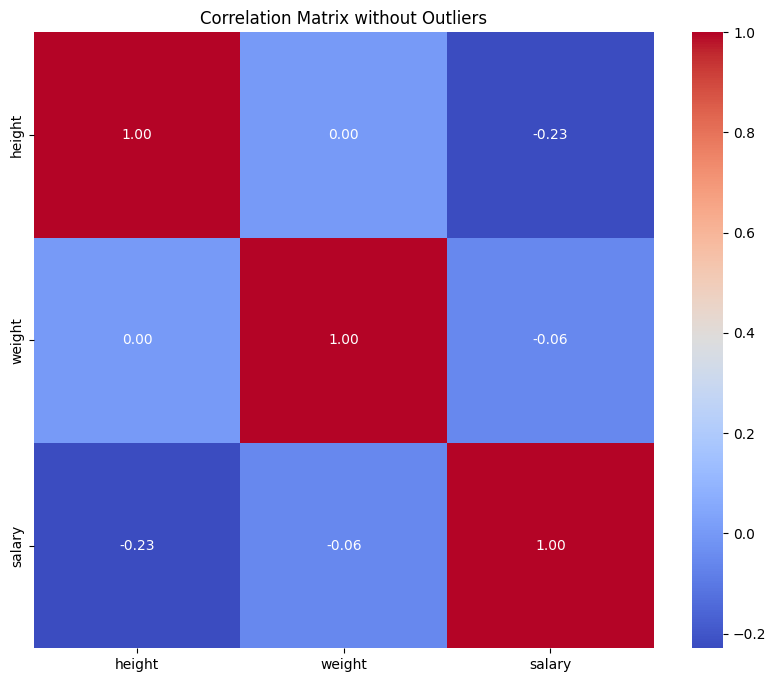

In [21]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()


In [22]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [23]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results


,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,174.802581,174.111306,8.824677,150.000000,210.0,60.000000,8.206793,0.802248,3.330725,0.0,0.0,2.0,2.0,6.0,6.0
weight,100.0,71.397280,70.841072,13.932214,40.000000,130.0,90.000000,14.390494,1.587588,4.962706,0.0,0.0,3.0,3.0,4.0,4.0
salary,100.0,70575.816571,38441.915870,138019.017873,9931.760814,1000000.0,990068.239186,23348.615150,4.740303,23.787349,0.0,0.0,5.0,5.0,7.0,7.0


In [24]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            mahal = np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [25]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")


Multivariate outliers: 0 found at indices []


<Figure size 1200x1000 with 0 Axes>

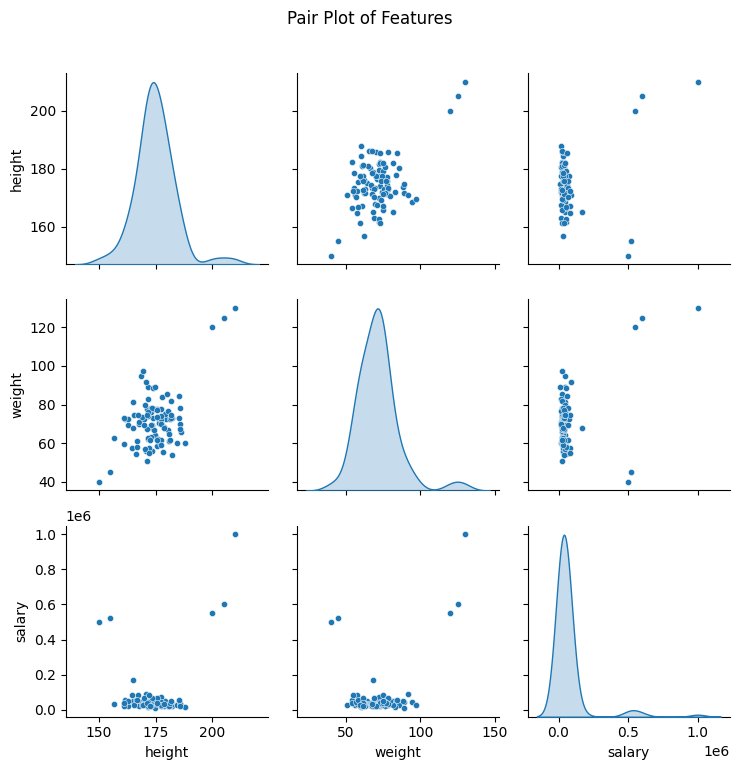

In [26]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4600\3117540217.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


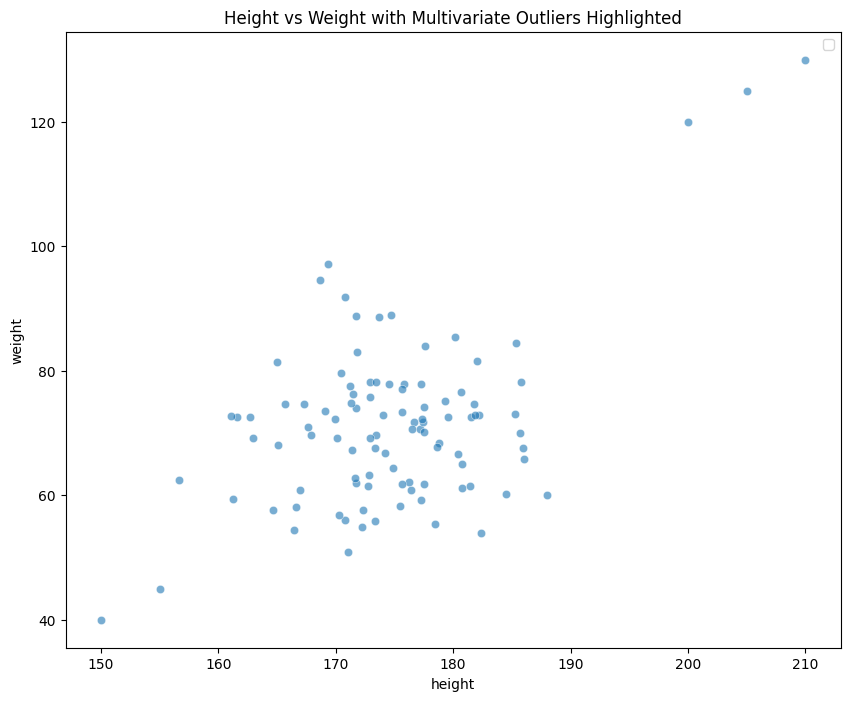

In [27]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


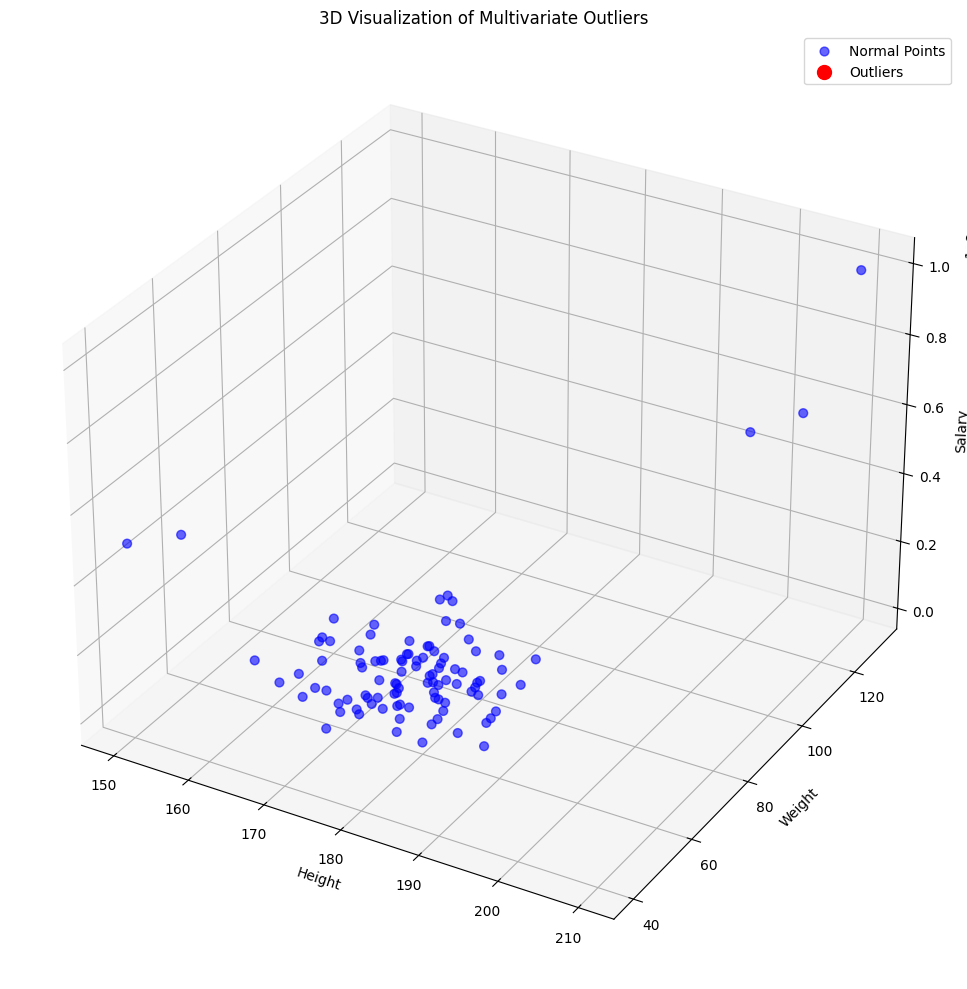

In [28]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()


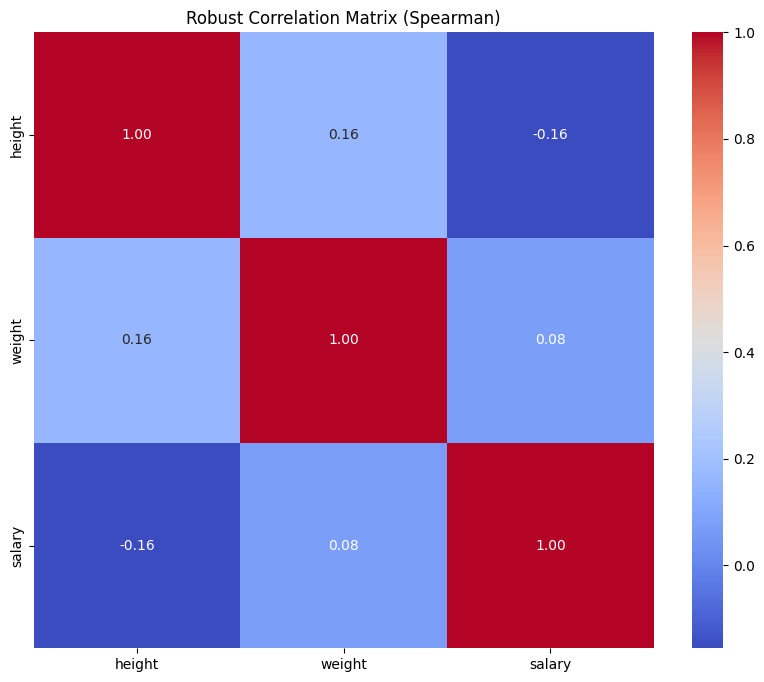

In [29]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()


In [30]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [31]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)


In [32]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

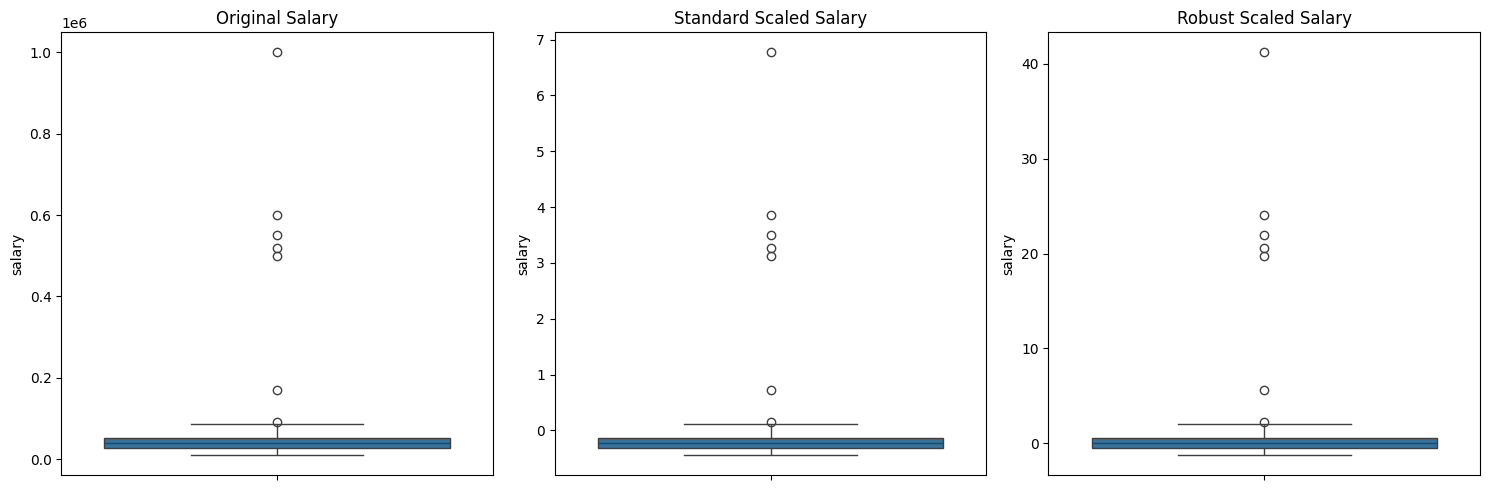

In [33]:
# Compare the scaled distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')

plt.tight_layout()
plt.show()


In [34]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [35]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'With Outlier: y = 2.57x + 1.40')

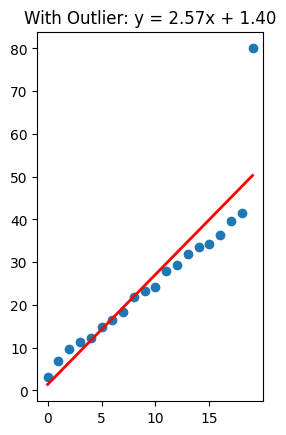

In [36]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')


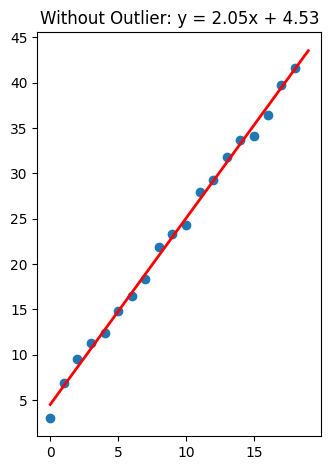

In [37]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

# Interactive Coding Exercise: Advanced Outlier Detection & Analysis


In [38]:
# ----------------------------------------------------------------
# In this exercise, you'll work with a real-world dataset to:
# 1. Apply outlier detection techniques
# 2. Compare methods and their impact
# 3. Implement a custom outlier detection workflow

In [39]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the California housing dataset instead of Boston
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Create a DataFrame with all features plus the target
df = X.copy()
df['MedHouseVal'] = y  # The target is median house value

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


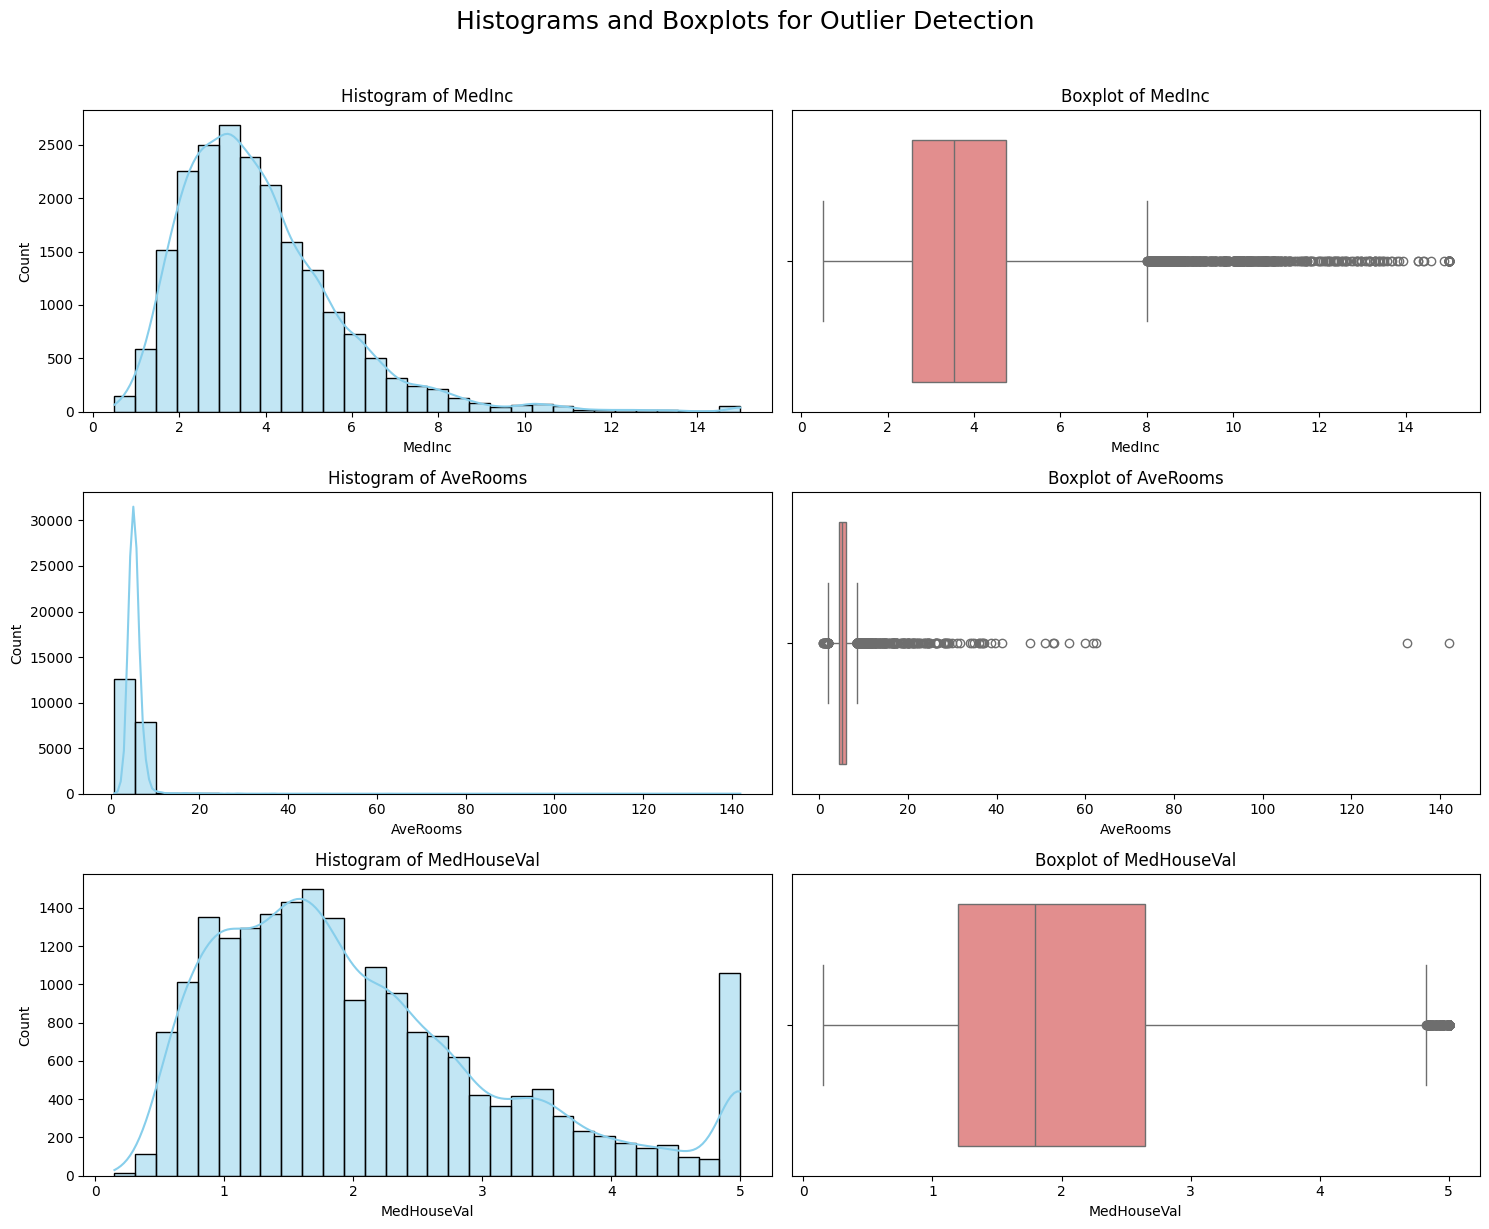

In [60]:
# EXERCISE 1: Exploratory Data Analysis for Outlier Detection

# We'll visualize 3 features: 'MedInc', 'AveRooms', and 'MedHouseVal'
# -----------------------------------------------------------
# TODO: Create histograms and boxplots for at least 3 features to visually identify outliers
# Hint: Use subplot to organize multiple plots

# Your code here (replace this with your solution)
features = ['MedInc', 'AveRooms', 'MedHouseVal']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Histograms and Boxplots for Outlier Detection', fontsize=18, y=1.02)

for i, feature in enumerate(features):
    # Histogram
    sns.histplot(df[feature], bins=30, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histogram of {feature}')
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Count')
    
    # Boxplot
    sns.boxplot(x=df[feature], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot of {feature}')
    axes[i, 1].set_xlabel(feature)

plt.tight_layout()
plt.show()


In [52]:
# EXERCISE 2: Implement Multiple Outlier Detection Methods
# -------------------------------------------------------
# TODO: Implement both Z-score and IQR outlier detection for the LSTAT feature
# LSTAT: % lower status of the population

# Your implementation here
# We'll use the 'LSTAT' feature for outlier detection.
# However, the California housing dataset does not have 'LSTAT' (from Boston housing).
# Let's use 'MedInc' (Median Income) as an analogous feature for this exercise.

feature = 'MedInc'

# Z-score method
from scipy.stats import zscore
z_scores = zscore(df[feature])
z_thresh = 3
z_outliers = (abs(z_scores) > z_thresh)

print(f"Z-score outliers in '{feature}': {z_outliers.sum()} out of {len(df)}")

# IQR method
Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)
IQR = Q3 - Q1
iqr_lower = Q1 - 1.5 * IQR
iqr_upper = Q3 + 1.5 * IQR
iqr_outliers = (df[feature] < iqr_lower) | (df[feature] > iqr_upper)

print(f"IQR outliers in '{feature}': {iqr_outliers.sum()} out of {len(df)}")





Z-score outliers in 'MedInc': 345 out of 20640
IQR outliers in 'MedInc': 681 out of 20640


In [54]:
# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------
# TODO: Implement the Isolation Forest algorithm to detect outliers in the dataset
# Use contamination=0.05 (assuming 5% of data points are outliers)
# Return a binary mask where -1 represents outliers

# Your implementation here
from sklearn.ensemble import IsolationForest

# We'll use the same feature as above, but Isolation Forest can work with multiple features.
# For demonstration, let's use all numerical features.
num_features = df.select_dtypes(include='number').columns

# Fit Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso_forest.fit_predict(df[num_features])

# Create a binary mask: -1 for outliers, 1 for inliers
iso_outliers = (iso_labels == -1)

print(f"Isolation Forest outliers: {iso_outliers.sum()} out of {len(df)}")


Isolation Forest outliers: 1032 out of 20640


In [61]:
# EXERCISE 4: Compare the Impact of Outliers on Linear Regression
# --------------------------------------------------------------
# TODO:
# 1. Create a simple linear regression model using 'LSTAT' to predict 'PRICE'

# 2. Create 3 versions:
#    a. With all data
#    b. After removing Z-score outliers
#    c. After removing Isolation Forest outliers
# 3. Compare the model performance metrics (r2_score) and coefficients

# Load Boston housing dataset and prepare DataFrame with correct columns
# 1. Linear regression with all data
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
import pandas as pd

# X and y
X = df[['MedInc']]
y = df['MedHouseVal']

model_all = LinearRegression()
model_all.fit(X, y)
y_pred_all = model_all.predict(X)
r2_all = r2_score(y, y_pred_all)
coef_all = model_all.coef_[0]
intercept_all = model_all.intercept_
print(f"All data: R2 = {r2_all:.4f}, Coef = {coef_all:.4f}, Intercept = {intercept_all:.4f}")

# 2. Remove Z-score outliers and fit model
z_scores = np.abs(zscore(df['MedInc']))
df_z = df[z_scores < 3]
X_z = df_z[['MedInc']]
y_z = df_z['MedHouseVal']
model_z = LinearRegression()
model_z.fit(X_z, y_z)
y_pred_z = model_z.predict(X_z)
r2_z = r2_score(y_z, y_pred_z)
coef_z = model_z.coef_[0]
intercept_z = model_z.intercept_
print(f"Z-score outliers removed: R2 = {r2_z:.4f}, Coef = {coef_z:.4f}, Intercept = {intercept_z:.4f}")

# 3. Remove Isolation Forest outliers and fit model
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(df[['MedInc']])
df_iso = df[outliers == 1]
X_iso = df_iso[['MedInc']]
y_iso = df_iso['MedHouseVal']
model_iso = LinearRegression()
model_iso.fit(X_iso, y_iso)
y_pred_iso = model_iso.predict(X_iso)
r2_iso = r2_score(y_iso, y_pred_iso)
coef_iso = model_iso.coef_[0]
intercept_iso = model_iso.intercept_
print(f"Isolation Forest outliers removed: R2 = {r2_iso:.4f}, Coef = {coef_iso:.4f}, Intercept = {intercept_iso:.4f}")

# 4. Summary Table
summary = pd.DataFrame({
    'Version': ['All Data', 'Z-score Outliers Removed', 'Isolation Forest Outliers Removed'],
    'R2 Score': [r2_all, r2_z, r2_iso],
    'Coefficient': [coef_all, coef_z, coef_iso],
    'Intercept': [intercept_all, intercept_z, intercept_iso]
})
display(summary)


All data: R2 = 0.4734, Coef = 0.4179, Intercept = 0.4509
Z-score outliers removed: R2 = 0.4321, Coef = 0.4521, Intercept = 0.3317
Isolation Forest outliers removed: R2 = 0.3844, Coef = 0.4531, Intercept = 0.3182


,Version,R2 Score,Coefficient,Intercept
0,All Data,0.473447,0.417938,0.450856
1,Z-score Outliers Removed,0.432059,0.452109,0.331711
2,Isolation Forest Outliers Removed,0.384363,0.453103,0.318160


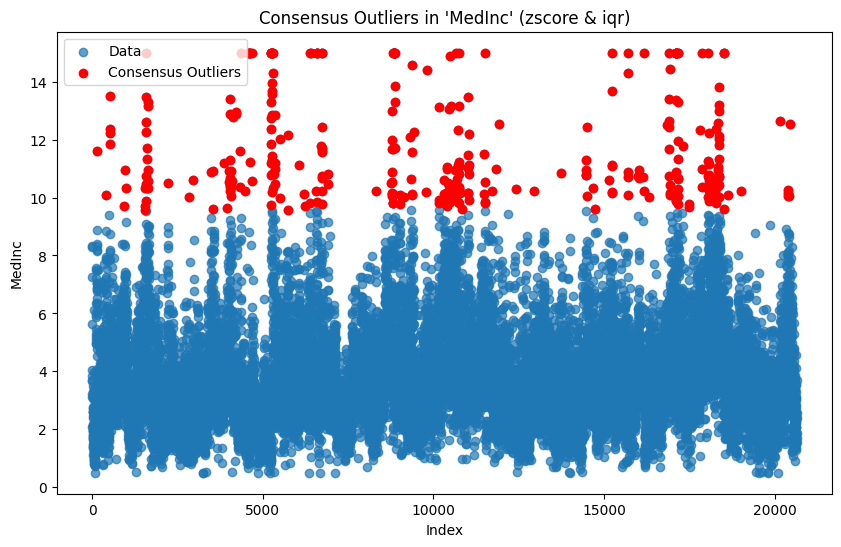

Consensus outlier indices: [131, 409, 510, 511, 512, 514, 923, 977, 986, 1541, 1561, 1563, 1564, 1566, 1574, 1582, 1583, 1586, 1591, 1593, 1602, 1617, 1621, 1636, 1637, 1644, 1645, 1646, 2213, 2826, 2969, 3486, 3533, 3542, 3858, 3953, 4014, 4018, 4042, 4044, 4045, 4046, 4047, 4049, 4050, 4056, 4070, 4074, 4111, 4116, 4220, 4229, 4319, 4345, 4352, 4492, 4604, 4605, 4606, 4622, 4626, 4677, 4678, 5242, 5243, 5244, 5246, 5247, 5248, 5250, 5252, 5253, 5254, 5256, 5257, 5258, 5259, 5260, 5264, 5269, 5271, 5272, 5275, 5277, 5281, 5291, 5292, 5304, 5318, 5352, 5360, 5361, 5368, 5493, 5494, 5728, 5738, 6073, 6204, 6226, 6389, 6391, 6399, 6551, 6576, 6590, 6591, 6592, 6712, 6720, 6724, 6725, 6726, 6727, 6728, 6731, 6732, 6735, 6736, 6915, 6919, 8311, 8768, 8790, 8792, 8793, 8794, 8795, 8796, 8797, 8799, 8800, 8805, 8806, 8809, 8814, 8816, 8817, 8846, 8847, 8848, 8849, 8850, 8851, 8852, 8853, 8854, 8875, 8876, 8878, 8882, 9010, 9011, 9136, 9316, 9354, 9356, 9370, 9381, 9382, 9418, 9794, 9811, 101

In [62]:
# EXERCISE 5: Create Your Own Outlier Detection Workflow
# -----------------------------------------------------
# TODO: Create a custom outlier detection function that combines multiple methods
# It should:
# 1. Take a dataframe and column name as input
# 2. Apply at least 2 different outlier detection methods (of your choice)
# 3. Return the indices of consensus outliers (detected by both methods)
# 4. Include a visualization of the outliers

# Your implementation here
def consensus_outliers(df, col, method1='zscore', method2='iqr', z_thresh=3, iqr_factor=1.5, plot=True):
    """
    Detect consensus outliers in a column using two methods.
    Returns indices of consensus outliers and shows a plot.
    """
    x = df[col]
    # Method 1: Z-score
    if method1 == 'zscore':
        z_scores = np.abs(zscore(x))
        outliers1 = set(df.index[z_scores > z_thresh])
    elif method1 == 'iqr':
        Q1 = x.quantile(0.25)
        Q3 = x.quantile(0.75)
        IQR = Q3 - Q1
        outliers1 = set(df.index[(x < Q1 - iqr_factor * IQR) | (x > Q3 + iqr_factor * IQR)])
    else:
        raise ValueError("Unknown method1")
    # Method 2: IQR or Isolation Forest
    if method2 == 'iqr':
        Q1 = x.quantile(0.25)
        Q3 = x.quantile(0.75)
        IQR = Q3 - Q1
        outliers2 = set(df.index[(x < Q1 - iqr_factor * IQR) | (x > Q3 + iqr_factor * IQR)])
    elif method2 == 'isoforest':
        iso = IsolationForest(contamination=0.05, random_state=42)
        preds = iso.fit_predict(x.values.reshape(-1, 1))
        outliers2 = set(df.index[preds == -1])
    elif method2 == 'zscore':
        z_scores = np.abs(zscore(x))
        outliers2 = set(df.index[z_scores > z_thresh])
    else:
        raise ValueError("Unknown method2")
    # Consensus: intersection
    consensus = sorted(list(outliers1 & outliers2))
    if plot:
        plt.figure(figsize=(10, 6))
        plt.scatter(df.index, x, label='Data', alpha=0.7)
        plt.scatter(consensus, x.loc[consensus], color='red', label='Consensus Outliers', zorder=5)
        plt.title(f"Consensus Outliers in '{col}' ({method1} & {method2})")
        plt.xlabel('Index')
        plt.ylabel(col)
        plt.legend()
        plt.show()
    return consensus

# Example usage:
consensus_idx = consensus_outliers(df, 'MedInc', method1='zscore', method2='iqr')
print("Consensus outlier indices:", consensus_idx)


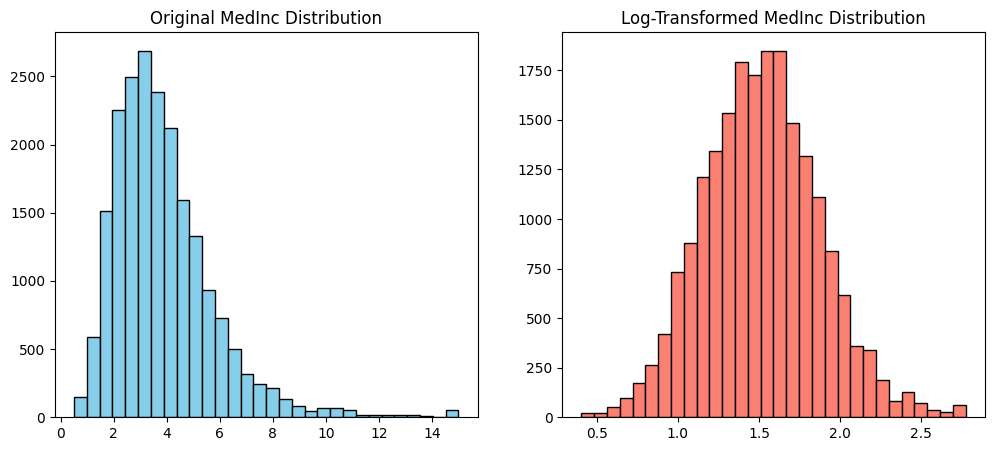

,MedInc,MedInc_log,MedInc_bin,Income_per_room
0,8.3252,2.232720,4,1.192017
1,8.3014,2.230165,4,1.330750
2,7.2574,2.111110,4,0.875637
3,5.6431,1.893579,4,0.970046
4,3.8462,1.578195,2,0.612272


In [65]:
# EXERCISE 6: Robust Feature Engineering with Outliers
# ---------------------------------------------------
# TODO: Create a new feature that is more robust to outliers
# Suggestions:
# - Use log transformation
# - Use binning/discretization
# - Create a ratio or interaction feature
# Compare the distribution before and after your transformation

# Your implementation here
# Example: Create a log-transformed version of 'salary' to reduce the effect of outliers

import numpy as np
import matplotlib.pyplot as plt

# 1. Log transformation (to reduce the effect of outliers)
df['MedInc_log'] = np.log1p(df['MedInc'])  # log1p handles zero values safely

# 2. Binning/discretization (e.g., quantile-based bins)
df['MedInc_bin'] = pd.qcut(df['MedInc'], q=5, labels=False)

# 3. Ratio/interaction feature (e.g., income per room)
df['Income_per_room'] = df['MedInc'] / df['AveRooms']

# Compare the distribution before and after log transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['MedInc'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Original MedInc Distribution')
axes[1].hist(df['MedInc_log'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Log-Transformed MedInc Distribution')
plt.show()

# Show the first few rows of the new features
df[['MedInc', 'MedInc_log', 'MedInc_bin', 'Income_per_room']].head()






Number of multivariate outliers detected: 403


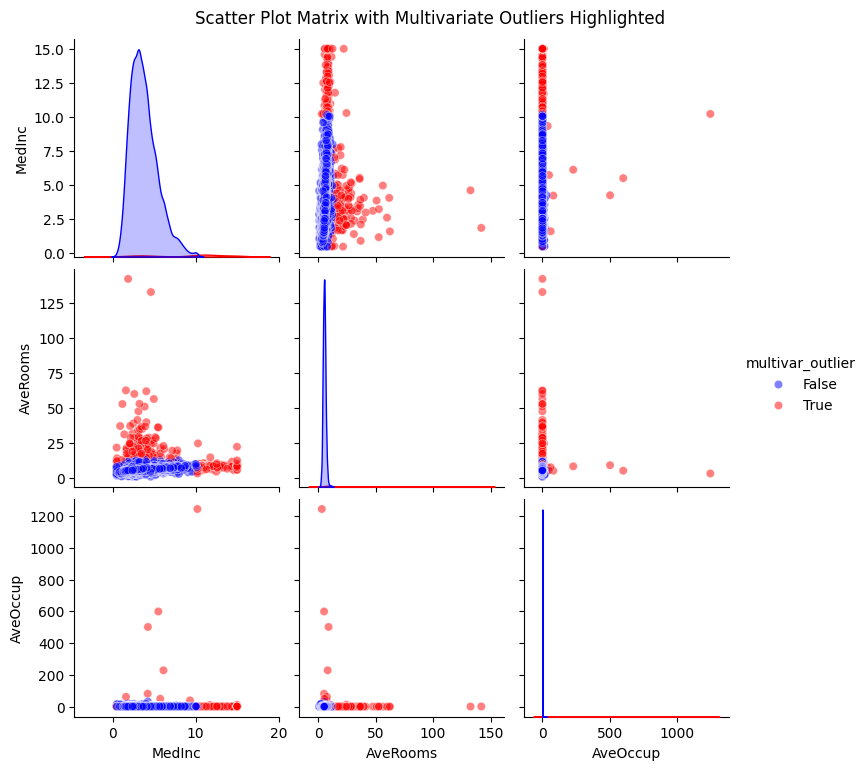

In [66]:
# EXERCISE 7: BONUS CHALLENGE - Multivariate Outlier Detection
# ------------------------------------------------------------
# TODO: Implement a multivariate outlier detection method using Mahalanobis distance
# Calculate the distance for each point and identify outliers using a chi-squared threshold
# Visualize the results using a scatter plot matrix highlighting the outliers

# Your implementation here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from scipy.spatial.distance import mahalanobis
import seaborn as sns

# Select a few features for multivariate outlier detection
features = ['MedInc', 'AveRooms', 'AveOccup']
X = df[features].values

# Compute the mean and covariance matrix
mean_vec = np.mean(X, axis=0)
cov_matrix = np.cov(X, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# Compute Mahalanobis distance for each point
m_dist = np.array([mahalanobis(x, mean_vec, inv_cov_matrix) for x in X])

# Chi-squared threshold for 3 features at 0.99 confidence
threshold = np.sqrt(chi2.ppf(0.99, df=len(features)))

# Identify outliers
outliers = m_dist > threshold

print(f"Number of multivariate outliers detected: {np.sum(outliers)}")

# Add Mahalanobis distance and outlier flag to DataFrame
df['mahalanobis_dist'] = m_dist
df['multivar_outlier'] = outliers

# Visualize with a scatter plot matrix, highlighting outliers
sns.pairplot(df, vars=features, hue='multivar_outlier', palette={False: 'blue', True: 'red'}, plot_kws={'alpha': 0.5})
plt.suptitle('Scatter Plot Matrix with Multivariate Outliers Highlighted', y=1.02)
plt.show()